In [1]:
pip install -U openai-whisper

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 803.2/803.2 kB 36.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for openai-whisper: filename=openai_whisper-20250625-py3-none-any.whl size=803979 sha256=56be895e33cf6182523df4488c2d878c2e87dda96d3424750557a471773cdc7c
  Stored in directory: /root/.cache/pip/wheels/61/d2/20/09ec9bef734d126cba375b15898010b6cc28578d8afdde5869
Successfully built openai-whisper


In [2]:
from google.colab import drive
drive.mount('/content/drive')
# Importation de l'excel pour les id (savoir ensuite quelle id correspond a quelle speaker)
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

file_path = '/content/drive/MyDrive/Projet Deep Learning/dataset_script_excel.xlsx'
dataset_excel = pd.read_excel(file_path)
display(dataset_excel.head())

# Speaker 1 : Train 700 audios
# Speaker 2 : Val 150 audios
# Speaker 3 : Test 150 audios

Mounted at /content/drive


,id,script,severity,speaker_id
0,1,"Easyfly 886, we have an elderly man in row 24 ...",URGENCY,1
1,2,"Golf Hotel 9, position report, overhead LIMA a...",NORMAL,1
2,3,"TUI 122, we have a passenger in row 39 who is ...",URGENCY,1
3,4,"Sierra 22, we have a woman in row 10 who has a...",URGENCY,1
4,5,"King Air Kilo 9, position report, overhead LIM...",NORMAL,1


In [3]:
print("\n--- AUDIT DU DATASET : DOUBLONS ET SIMILARITÉS ---")

# 1. Vérification des doublons exacts
# On regarde si certaines lignes ont exactement le même texte dans la colonne 'script'
exact_duplicates = dataset_excel[dataset_excel.duplicated(subset=['script'], keep=False)]

if not exact_duplicates.empty:
    print(f"\n⚠️ {len(exact_duplicates)} phrases exactement identiques trouvées :")
    display(exact_duplicates.sort_values(by='script')[['id', 'script', 'severity']])
else:
    print("\n✅ Aucun doublon exact trouvé dans la colonne 'script'.")

# 2. Vérification de la haute similarité (pour éviter la fuite de templates)
print("\nAnalyse des similarités textuelles en cours (TF-IDF + Cosinus)...")

# Vectorisation des textes
vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(dataset_excel['script'].astype(str))

# Calcul de la matrice de similarité (comparaison de chaque phrase avec toutes les autres)
cosine_sim = cosine_similarity(tfidf_matrix)

# Définition du seuil d'alerte (0.85 signifie que les textes sont similaires à 85% ou plus)
SEUIL_SIMILARITE = 0.85

similar_pairs = []

# On parcourt la moitié de la matrice pour éviter les redondances (comparer A avec B, puis B avec A)
for i in range(len(cosine_sim)):
    for j in range(i + 1, len(cosine_sim)):
        if cosine_sim[i, j] >= SEUIL_SIMILARITE:
            similar_pairs.append({
                'id_1': dataset_excel.iloc[i]['id'],
                'script_1': dataset_excel.iloc[i]['script'],
                'id_2': dataset_excel.iloc[j]['id'],
                'script_2': dataset_excel.iloc[j]['script'],
                'similarité': round(cosine_sim[i, j], 3)
            })

if similar_pairs:
    print(f"\n⚠️ {len(similar_pairs)} paires de textes hautement similaires (>= {SEUIL_SIMILARITE}) trouvées.")
    print("Vérifiez que ces paires ne se retrouvent pas séparées dans vos sets Train et Test :")
    df_similar = pd.DataFrame(similar_pairs)
    # Affichage des pires cas en premier
    display(df_similar.sort_values(by='similarité', ascending=False).head(20))
else:
    print(f"\n✅ Aucune paire avec une similarité problématique (>= {SEUIL_SIMILARITE}) n'a été trouvée.")


--- AUDIT DU DATASET : DOUBLONS ET SIMILARITÉS ---

✅ Aucun doublon exact trouvé dans la colonne 'script'.

Analyse des similarités textuelles en cours (TF-IDF + Cosinus)...

⚠️ 28 paires de textes hautement similaires (>= 0.85) trouvées.
Vérifiez que ces paires ne se retrouvent pas séparées dans vos sets Train et Test :


,id_1,script_1,id_2,script_2,similarité
17,526,"PAN PAN, PAN PAN, PAN PAN, Cherokee Victor 1, ...",607,"PAN PAN, PAN PAN, PAN PAN, Polar 88, we have a...",0.922
13,378,"MAYDAY MAYDAY MAYDAY, Alpha Romeo 5, engine on...",533,"MAYDAY MAYDAY MAYDAY, Pilatus Alpha 2, engine ...",0.918
27,958,"PAN PAN, PAN PAN, PAN PAN, Monarch 77, we have...",974,"PAN PAN, PAN PAN, PAN PAN, Navajo November 4, ...",0.914
2,22,"PAN PAN, PAN PAN, PAN PAN, Mike November 31, w...",939,"PAN PAN, PAN PAN, PAN PAN, Flybe 39, we have a...",0.906
7,56,"PAN PAN, PAN PAN, PAN PAN, Monarch 77, we have...",939,"PAN PAN, PAN PAN, PAN PAN, Flybe 39, we have a...",0.906
0,8,"Lufthansa 404, overhead ALPHA at FL330, estima...",102,"Lufthansa 404, overhead TANGO at FL330, estima...",0.901
6,45,"PAN PAN, PAN PAN, PAN PAN, Falcon 7X Golf, we ...",699,"PAN PAN, PAN PAN, PAN PAN, Falcon 7X Golf, we ...",0.898
1,22,"PAN PAN, PAN PAN, PAN PAN, Mike November 31, w...",56,"PAN PAN, PAN PAN, PAN PAN, Monarch 77, we have...",0.898
14,444,"PAN PAN, PAN PAN, PAN PAN, Jet2 541, we have a...",808,"PAN PAN, PAN PAN, PAN PAN, Baron Sierra 5, we ...",0.896
15,454,"PAN PAN, PAN PAN, PAN PAN, Helvetic 88, we hav...",823,"PAN PAN, PAN PAN, PAN PAN, Sunwing 44, we have...",0.894


Transcription avec Whisper

In [ ]:
import pandas as pd
import whisper
import json
import os

# 1. Nouveaux chemins
excel_path = '/content/drive/MyDrive/Projet Deep Learning/dataset_script_excel.xlsx'
audio_folder = '/content/drive/MyDrive/Projet Deep Learning/data/audio/'
jsonl_output_path = '/content/drive/MyDrive/Projet Deep Learning/data/dataset.jsonl'

# 2. Chargement des données Excel et du modèle Whisper
print("Chargement du fichier Excel...")
df = pd.read_excel(excel_path)

print("Chargement du modèle Whisper...")
whisper_model = whisper.load_model("small")

# 3. Traitement et création du JSONL
print("Début de la transcription et de la création du JSONL...")

with open(jsonl_output_path, 'w', encoding='utf-8') as jsonl_file:

    for index, row in df.iterrows():
        # Formatage de l'ID : 1 devient "ex_0001"
        file_id = f"ex_{int(row['id']):04d}"
        audio_filename = f"{file_id}.wav"

        # On regarde d'abord dans le dossier d'origine
        audio_path = os.path.join(audio_folder, audio_filename)

        # Si le fichier est trouvé (dans l'un ou l'autre des dossiers)
        if os.path.exists(audio_path):
            print(f"Transcription de {audio_filename} en cours...")

            # Transcription avec Whisper
            result = whisper_model.transcribe(audio_path)
            whisper_text = result["text"].strip()

            # Création du dictionnaire selon le format exigé
            data_entry = {
                "id": file_id,
                "whisper_text": whisper_text,
                "severity": str(row['severity']),
                "speaker_id": str(row['speaker_id'])
            }

            # Écriture dans le JSONL
            jsonl_file.write(json.dumps(data_entry, ensure_ascii=False) + '\n')
        else:
            print(f"⚠️ Fichier ignoré : {audio_filename} introuvable ni dans audio/ ni dans audio_augmented/.")

print(f"\n✅ Fichier dataset.jsonl généré avec succès !")

Chargement du fichier Excel...
Chargement du modèle Whisper...


 61%|███████████████████████▋               | 281M/461M [00:03<00:02, 92.9MiB/s]


KeyboardInterrupt: 

In [6]:
import json

jsonl_output_path = '/content/drive/MyDrive/Projet Deep Learning/data/dataset.jsonl'

print("\nAffichage des 10 premières lignes du fichier JSONL :")
with open(jsonl_output_path, 'r', encoding='utf-8') as f:
    for i, line in enumerate(f):
        if i >= 10:
            break
        print(json.dumps(json.loads(line), indent=2, ensure_ascii=False))


Affichage des 10 premières lignes du fichier JSONL :
{
  "id": "ex_0001",
  "whisper_text": "By 886 we have an early man in ROW24 with showing extreme agitation and threatening other passengers, requesting paramedics underground.",
  "severity": "URGENCY",
  "speaker_id": "1"
}
{
  "id": "ex_0002",
  "whisper_text": "Hotel 9 position report, overhead Lima at flight level 330 estimer Lima Next.",
  "severity": "NORMAL",
  "speaker_id": "1"
}
{
  "id": "ex_0003",
  "whisper_text": "On a une avion de Pat persones succeedede avec des veau meeting ou Assassin's Creed 132 without having to have a medical facilities. On est éteintsurry.",
  "severity": "URGENCY",
  "speaker_id": "1"
}
{
  "id": "ex_0004",
  "whisper_text": "Sierra 22, on a une femme en Ro 10, c'était une très rapide hôte que la crew peut ressentir, demandant l'assistance médicale à l'arrivée.",
  "severity": "URGENCY",
  "speaker_id": "1"
}
{
  "id": "ex_0005",
  "whisper_text": "King Air K9 Position Report, overhead Lima at

Split du dataset

In [8]:
import os

jsonl_path = '/content/drive/MyDrive/Projet Deep Learning/data/dataset.jsonl'
splits_dir = '/content/drive/MyDrive/Projet Deep Learning/data/splits/'

# 1. Chargement du dataset JSONL
data = []
with open(jsonl_path, 'r', encoding='utf-8') as f:
    for line in f:
        data.append(json.loads(line))

df = pd.DataFrame(data)

print(f"Dataset chargé avec {len(df)} exemples.")
print("Locuteurs présents :", df['speaker_id'].unique())

# 3. Stratégie de séparation (À ADAPTER SELON TES LOCUTEURS)
# Ici, on associe manuellement chaque speaker à un split pour éviter le "speaker leakage"
# Modifie les valeurs '1', '2', '3' selon ce que tu as mis dans ton Excel
speaker_mapping = {
    '1': 'train',  # Le locuteur 1 va dans le set d'entraînement (idéalement celui qui a enregistré le plus de phrases)
    '2': 'val',    # Le locuteur 2 va dans la validation
    '3': 'test'    # Le locuteur 3 va dans le test
}

# 4. Répartition des IDs
train_ids = df[df['speaker_id'].map(speaker_mapping) == 'train']['id'].tolist()
val_ids = df[df['speaker_id'].map(speaker_mapping) == 'val']['id'].tolist()
test_ids = df[df['speaker_id'].map(speaker_mapping) == 'test']['id'].tolist()

# 5. Sauvegarde dans les fichiers .txt
def save_ids(ids_list, filename):
    filepath = os.path.join(splits_dir, filename)
    with open(filepath, 'w', encoding='utf-8') as f:
        for item in ids_list:
            f.write(f"{item}\n")
    print(f"✅ {filename} créé avec {len(ids_list)} IDs.")

save_ids(train_ids, 'train_ids.txt')
save_ids(val_ids, 'val_ids.txt')
save_ids(test_ids, 'test_ids.txt')

# Petit bilan
total = len(df)
print(f"\nRépartition finale :")
print(f"Train : {len(train_ids)} ({len(train_ids)/total*100:.1f}%)")
print(f"Val   : {len(val_ids)} ({len(val_ids)/total*100:.1f}%)")
print(f"Test  : {len(test_ids)} ({len(test_ids)/total*100:.1f}%)")


Dataset chargé avec 1000 exemples.
Locuteurs présents : ['1' '2' '3']
✅ train_ids.txt créé avec 700 IDs.
✅ val_ids.txt créé avec 150 IDs.
✅ test_ids.txt créé avec 150 IDs.

Répartition finale :
Train : 700 (70.0%)
Val   : 150 (15.0%)
Test  : 150 (15.0%)


Jeu de test chargé avec 150 exemples.

--- RÉSULTATS DE LA BASELINE 1 (MOTS-CLÉS) ---
Accuracy Globale : 0.79
Recall (URGENCY) : 0.45
Recall (DISTRESS): 0.55
Fausses Alarmes (Normal -> Urgence/Détresse) : 0 (0.0%)

✅ Matrice de confusion sauvegardée sous : /content/drive/MyDrive/Projet Deep Learning/outputs/reports/confusion_matrix_baseline1.png


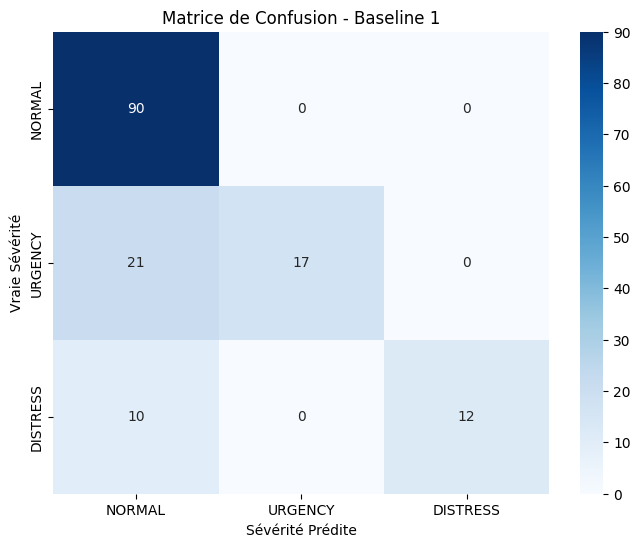

In [9]:
from sklearn.metrics import accuracy_score, recall_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 1. Chemins des fichiers
jsonl_path = '/content/drive/MyDrive/Projet Deep Learning/data/dataset.jsonl'
test_ids_path = '/content/drive/MyDrive/Projet Deep Learning/data/splits/test_ids.txt'
reports_dir = '/content/drive/MyDrive/Projet Deep Learning/outputs/reports/'

# 2. Chargement des IDs du jeu de test
with open(test_ids_path, 'r', encoding='utf-8') as f:
    test_ids = set(line.strip() for line in f)

# 3. Chargement uniquement des données de test
test_data = []
with open(jsonl_path, 'r', encoding='utf-8') as f:
    for line in f:
        item = json.loads(line)
        if item['id'] in test_ids:
            test_data.append(item)

df_test = pd.DataFrame(test_data)
print(f"Jeu de test chargé avec {len(df_test)} exemples.")

# 4. Fonction de la Baseline 1 (Règles Mots-clés)
def keyword_baseline(text):
    # On met tout en minuscules pour ne pas rater des mots à cause des majuscules
    text_lower = str(text).lower()
    if "mayday" in text_lower:
        return "DISTRESS"
    elif "pan pan" in text_lower:
        return "URGENCY"
    elif "panpan" in text_lower:
        return "URGENCY"
    else:
        return "NORMAL"

# 5. Application des prédictions sur les transcriptions Whisper
df_test['prediction'] = df_test['whisper_text'].apply(keyword_baseline)

# 6. ÉVALUATION (Génération des métriques demandées)
y_true = df_test['severity']
y_pred = df_test['prediction']
classes = ['NORMAL', 'URGENCY', 'DISTRESS']

# Accuracy globale
accuracy = accuracy_score(y_true, y_pred)

# Recall par classe
# average=None permet d'avoir le recall pour chaque classe séparément
recalls = recall_score(y_true, y_pred, labels=classes, average=None)
recall_urgency = recalls[1]
recall_distress = recalls[2]

# Calcul des fausses alarmes (Vrai = NORMAL, mais Prédit = URGENCY ou DISTRESS)
false_alarms = df_test[(df_test['severity'] == 'NORMAL') & (df_test['prediction'].isin(['URGENCY', 'DISTRESS']))]
false_alarm_rate = len(false_alarms) / len(df_test[df_test['severity'] == 'NORMAL']) * 100 if len(df_test[df_test['severity'] == 'NORMAL']) > 0 else 0

print("\n--- RÉSULTATS DE LA BASELINE 1 (MOTS-CLÉS) ---")
print(f"Accuracy Globale : {accuracy:.2f}")
print(f"Recall (URGENCY) : {recall_urgency:.2f}")
print(f"Recall (DISTRESS): {recall_distress:.2f}")
print(f"Fausses Alarmes (Normal -> Urgence/Détresse) : {len(false_alarms)} ({false_alarm_rate:.1f}%)")

# 7. Matrice de Confusion
cm = confusion_matrix(y_true, y_pred, labels=classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title('Matrice de Confusion - Baseline 1')
plt.ylabel('Vraie Sévérité')
plt.xlabel('Sévérité Prédite')

# Sauvegarde de la matrice comme demandé dans les livrables
cm_path = os.path.join(reports_dir, 'confusion_matrix_baseline1.png')
plt.savefig(cm_path)
print(f"\n✅ Matrice de confusion sauvegardée sous : {cm_path}")
plt.show()

Baseline 2 : TF-IDF + Logistic regression

Chargement des données...
Entraînement : 700 exemples | Test : 150 exemples.

Entraînement de la Baseline 2 (TF-IDF + Logistic Regression)...

--- RÉSULTATS DE LA BASELINE 2 (TF-IDF + LR) ---
Accuracy Globale : 0.99
Recall (URGENCY) : 1.00
Recall (DISTRESS): 0.91
Fausses Alarmes (Normal -> Urgence/Détresse) : 0 (0.0%)

✅ Matrice de confusion sauvegardée sous : /content/drive/MyDrive/Projet Deep Learning/outputs/reports/confusion_matrix_baseline2.png


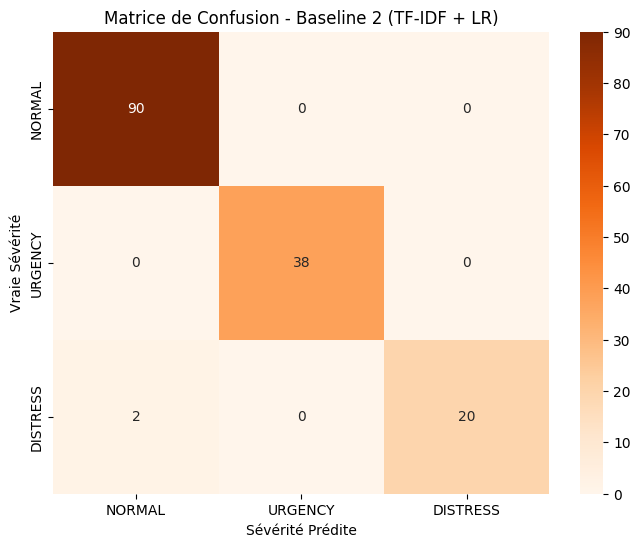

In [10]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, recall_score, confusion_matrix


# 1. Chemins des fichiers (Vérifie bien tes chemins)
jsonl_path = '/content/drive/MyDrive/Projet Deep Learning/data/dataset.jsonl'
train_ids_path = '/content/drive/MyDrive/Projet Deep Learning/data/splits/train_ids.txt'
test_ids_path = '/content/drive/MyDrive/Projet Deep Learning/data/splits/test_ids.txt'
reports_dir = '/content/drive/MyDrive/Projet Deep Learning/outputs/reports/'

# 2. Fonction pour charger les données selon les IDs
def load_data_from_ids(ids_path):
    with open(ids_path, 'r', encoding='utf-8') as f:
        valid_ids = set(line.strip() for line in f)

    data = []
    with open(jsonl_path, 'r', encoding='utf-8') as f:
        for line in f:
            item = json.loads(line)
            if item['id'] in valid_ids:
                data.append(item)
    return pd.DataFrame(data)

# Chargement du Train et du Test
print("Chargement des données...")
df_train = load_data_from_ids(train_ids_path)
df_test = load_data_from_ids(test_ids_path)
print(f"Entraînement : {len(df_train)} exemples | Test : {len(df_test)} exemples.")

# 3. Préparation des données textuelles (Whisper) et des labels (Sévérité)
X_train = df_train['whisper_text']
y_train = df_train['severity']
X_test = df_test['whisper_text']
y_test = df_test['severity']

# 4. Modélisation : TF-IDF + Régression Logistique
print("\nEntraînement de la Baseline 2 (TF-IDF + Logistic Regression)...")

# A. Transformation du texte en vecteurs TF-IDF
vectorizer = TfidfVectorizer()
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test) # Attention: on fait juste transform() sur le test !

# B. Entraînement de la Régression Logistique
# max_iter=1000 permet d'éviter les avertissements de convergence
clf = LogisticRegression(max_iter=1000)
clf.fit(X_train_tfidf, y_train)

# C. Prédiction sur le jeu de test
y_pred = clf.predict(X_test_tfidf)

# 5. ÉVALUATION (Génération des métriques demandées par le projet)
classes = ['NORMAL', 'URGENCY', 'DISTRESS']

# Accuracy globale
accuracy = accuracy_score(y_test, y_pred)

# Recall par classe
recalls = recall_score(y_test, y_pred, labels=classes, average=None)
recall_urgency = recalls[1]
recall_distress = recalls[2]

# Calcul des fausses alarmes (Vrai = NORMAL, mais Prédit = URGENCY ou DISTRESS)
false_alarms = df_test[(df_test['severity'] == 'NORMAL') & (pd.Series(y_pred).isin(['URGENCY', 'DISTRESS']))]
false_alarm_rate = len(false_alarms) / len(df_test[df_test['severity'] == 'NORMAL']) * 100 if len(df_test[df_test['severity'] == 'NORMAL']) > 0 else 0

print("\n--- RÉSULTATS DE LA BASELINE 2 (TF-IDF + LR) ---")
print(f"Accuracy Globale : {accuracy:.2f}")
print(f"Recall (URGENCY) : {recall_urgency:.2f}")
print(f"Recall (DISTRESS): {recall_distress:.2f}")
print(f"Fausses Alarmes (Normal -> Urgence/Détresse) : {len(false_alarms)} ({false_alarm_rate:.1f}%)")

# 6. Matrice de Confusion
cm = confusion_matrix(y_test, y_pred, labels=classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', xticklabels=classes, yticklabels=classes)
plt.title('Matrice de Confusion - Baseline 2 (TF-IDF + LR)')
plt.ylabel('Vraie Sévérité')
plt.xlabel('Sévérité Prédite')

cm_path = os.path.join(reports_dir, 'confusion_matrix_baseline2.png')
plt.savefig(cm_path)
print(f"\n✅ Matrice de confusion sauvegardée sous : {cm_path}")
plt.show()

Entrainement du modèle Xlm-Roberta-base

In [11]:
pip install transformers datasets evaluate accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 8.5 MB/s eta 0:00:00


In [12]:
import torch
import evaluate
import numpy as np
from datasets import Dataset, DatasetDict
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer

output_dir = '/content/drive/MyDrive/Projet Deep Learning/outputs/transformer/'
val_ids_path = '/content/drive/MyDrive/Projet Deep Learning/data/splits/val_ids.txt'

# 3. Fonction pour charger et préparer les données
def load_and_prepare_data(ids_path):
    with open(ids_path, 'r', encoding='utf-8') as f:
        valid_ids = set(line.strip() for line in f)

    data = []
    # Dictionnaire pour convertir tes textes en numéros pour le modèle
    label_map = {"NORMAL": 0, "URGENCY": 1, "DISTRESS": 2}

    with open(jsonl_path, 'r', encoding='utf-8') as f:
        for line in f:
            item = json.loads(line)
            if item['id'] in valid_ids:
                data.append({
                    "text": item['whisper_text'],
                    "label": label_map[item['severity']] # Le modèle a besoin d'entiers
                })
    return pd.DataFrame(data)

df_train = load_and_prepare_data(train_ids_path)
df_val = load_and_prepare_data(val_ids_path)

# Conversion en format Hugging Face Dataset
hf_dataset = DatasetDict({
    "train": Dataset.from_pandas(df_train),
    "validation": Dataset.from_pandas(df_val)
})

# 4. Tokenization (Préparation du texte pour XLM-ROBERTa)
model_checkpoint = "xlm-roberta-base"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

def tokenize_function(examples):
    # Max sequence length: 128 (recommandé dans le PDF)
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=128)

tokenized_datasets = hf_dataset.map(tokenize_function, batched=True)

# 5. Chargement du modèle avec 3 classes (NORMAL, URGENCY, DISTRESS)
# num_labels=3 crée la "Severity head" (3-class softmax)
model = AutoModelForSequenceClassification.from_pretrained(model_checkpoint, num_labels=3)

# 6. Définition des métriques pour l'évaluation pendant l'entraînement
metric = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return metric.compute(predictions=predictions, references=labels)

# 7. Configuration de l'entraînement
training_args = TrainingArguments(
    output_dir=output_dir,
    eval_strategy="epoch",       # Évaluation à la fin de chaque époque
    save_strategy="epoch",       # Sauvegarde à la fin de chaque époque
    learning_rate=2e-5,          # Learning rate recommandé
    per_device_train_batch_size=16, # Batch size recommandé
    per_device_eval_batch_size=16,
    num_train_epochs=5,          # Epochs recommandées
    weight_decay=0.01,
    optim="adamw_torch",
    load_best_model_at_end=True, # Garde le meilleur checkpoint basé sur la validation
    metric_for_best_model="eval_loss", # On minimise la fonction de perte
)

# 8. Lancement de l'entraînement
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
)

print("🚀 Lancement du fine-tuning XLM-ROBERTa...")
trainer.train()

print(f"\n✅ Entraînement terminé ! Le meilleur modèle est sauvegardé dans : {output_dir}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye


✅ Entraînement terminé ! Le meilleur modèle est sauvegardé dans : /content/drive/MyDrive/Projet Deep Learning/outputs/transformer/


Test du modèle

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Jeu de test : 150 exemples.
Calcul des prédictions...

=== RAPPORT D'ÉVALUATION COMPLET ===
Global Accuracy    : 100.00%
Recall URGENCY     : 100.00%
Recall DISTRESS    : 100.00%
False Alarm Rate   : 0.00% (0/90)

✅ Matrice de confusion sauvegardée sous : /content/drive/MyDrive/Projet Deep Learning/outputs/reports/confusion_matrix_transformer.png


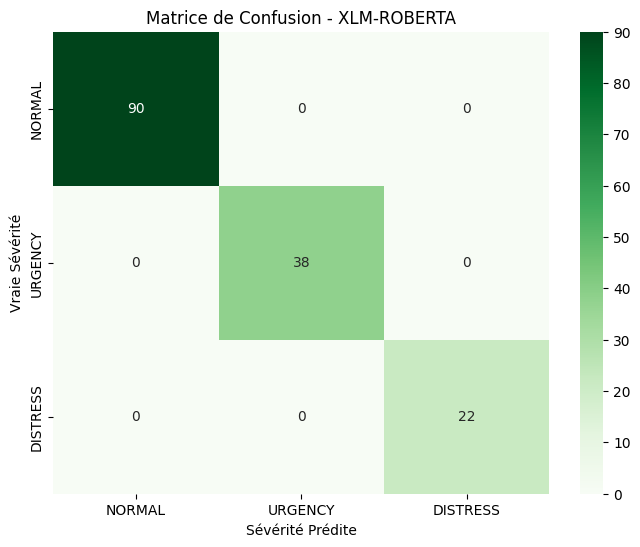


📂 Fichiers générés :
   1. /content/drive/MyDrive/Projet Deep Learning/outputs/reports/full_test_results.csv (Tous les résultats)
   2. /content/drive/MyDrive/Projet Deep Learning/outputs/reports/errors_for_analysis.csv (Liste des erreurs uniquement - Ouvre ce fichier pour ton rapport !)

✅ Aucune erreur détectée (Bravo ! ou dataset trop petit ^^)
Génération du fichier Markdown : /content/drive/MyDrive/Projet Deep Learning/outputs/reports/error_analysis.md ...
✅ Fichier error_analysis.md généré !
👉 Ouvre-le dans Colab (double-clique dessus à gauche), remplace les 'TO_FILL' par 'ASR' ou 'MODEL' ou 'DATA', et sauvegarde.


In [13]:
import torch
import pandas as pd
import numpy as np
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import accuracy_score, recall_score, confusion_matrix
import torch.nn.functional as F
import os
import json

# --- CONFIGURATION ---
test_ids_path = '/content/drive/MyDrive/Projet Deep Learning/data/splits/test_ids.txt'
jsonl_path = '/content/drive/MyDrive/Projet Deep Learning/data/dataset.jsonl'
model_dir = '/content/drive/MyDrive/Projet Deep Learning/outputs/transformer/checkpoint-220' # METTRE LE MEILLEUR CHECKPOINT (Le plus grand nombre)
reports_dir = '/content/drive/MyDrive/Projet Deep Learning/outputs/reports/'

# 1. Chargement des données et du modèle
tokenizer = AutoTokenizer.from_pretrained(model_dir)
model = AutoModelForSequenceClassification.from_pretrained(model_dir)

# Chargement du Test Set
with open(test_ids_path, 'r', encoding='utf-8') as f:
    valid_ids = set(line.strip() for line in f)

data = []
with open(jsonl_path, 'r', encoding='utf-8') as f:
    for line in f:
        item = json.loads(line)
        if item['id'] in valid_ids:
            data.append(item)

df_test = pd.DataFrame(data)
print(f"Jeu de test : {len(df_test)} exemples.")

# 2. Prédiction avec Confiance (Probabilités)
label_map = {"NORMAL": 0, "URGENCY": 1, "DISTRESS": 2}
inv_label_map = {0: "NORMAL", 1: "URGENCY", 2: "DISTRESS"}

predictions = []
confidences = []
probs_list = []

print("Calcul des prédictions...")
for text in df_test['whisper_text']:
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=128, padding=True)
    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits
        # On applique Softmax pour avoir des % (ex: 0.1, 0.8, 0.1)
        probs = F.softmax(logits, dim=-1).squeeze().tolist()

    pred_id = np.argmax(probs)
    predictions.append(inv_label_map[pred_id])
    confidences.append(probs[pred_id]) # La confiance est la proba de la classe choisie
    probs_list.append(probs)

df_test['predicted_label'] = predictions
df_test['confidence'] = confidences

# 3. Calcul des Métriques Avancées
y_true = df_test['severity']
y_pred = df_test['predicted_label']
classes = ['NORMAL', 'URGENCY', 'DISTRESS']

# Accuracy & Recall
acc = accuracy_score(y_true, y_pred)
recalls = recall_score(y_true, y_pred, labels=classes, average=None)

# --- FAUSSES ALARMES (False Alarms) ---
# Une fausse alarme, c'est quand c'est NORMAL en vrai, mais prédit URGENCY ou DISTRESS
false_alarms_df = df_test[
    (df_test['severity'] == 'NORMAL') &
    (df_test['predicted_label'].isin(['URGENCY', 'DISTRESS']))
]
nb_normal = len(df_test[df_test['severity'] == 'NORMAL'])
fa_rate = (len(false_alarms_df) / nb_normal * 100) if nb_normal > 0 else 0.0

print("\n=== RAPPORT D'ÉVALUATION COMPLET ===")
print(f"Global Accuracy    : {acc:.2%}")
print(f"Recall URGENCY     : {recalls[1]:.2%}")
print(f"Recall DISTRESS    : {recalls[2]:.2%}")
print(f"False Alarm Rate   : {fa_rate:.2f}% ({len(false_alarms_df)}/{nb_normal})")

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Calcul de la matrice de confusion
cm = confusion_matrix(y_true, y_pred, labels=classes)

# 2. Affichage visuel avec Seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=classes, yticklabels=classes)
plt.title('Matrice de Confusion - XLM-ROBERTA')
plt.ylabel('Vraie Sévérité')
plt.xlabel('Sévérité Prédite')

cm_path = os.path.join(reports_dir, 'confusion_matrix_transformer.png')
plt.savefig(cm_path)
print(f"\n✅ Matrice de confusion sauvegardée sous : {cm_path}")
plt.show()


# 4. Génération du fichier pour l'Analyse d'Erreurs
# On ne garde que les erreurs pour faciliter ton travail
errors_df = df_test[df_test['severity'] != df_test['predicted_label']].copy()

# On sauvegarde tout (erreurs + réussites) dans un CSV pour inspection
csv_path = os.path.join(reports_dir, 'full_test_results.csv')
df_test.to_csv(csv_path, index=False)

# On sauvegarde un fichier spécial "Erreurs à analyser"
errors_csv_path = os.path.join(reports_dir, 'errors_for_analysis.csv')
errors_df.to_csv(errors_csv_path, index=False)

print(f"\n📂 Fichiers générés :")
print(f"   1. {csv_path} (Tous les résultats)")
print(f"   2. {errors_csv_path} (Liste des erreurs uniquement - Ouvre ce fichier pour ton rapport !)")

# Exemple d'affichage des erreurs
if not errors_df.empty:
    print("\n--- Exemple d'erreurs détectées ---")
    display(errors_df[['whisper_text', 'severity', 'predicted_label', 'confidence']].head())
else:
    print("\n✅ Aucune erreur détectée (Bravo ! ou dataset trop petit ^^)")



# Création du fichier md
md_path = os.path.join(reports_dir, 'error_analysis.md')

print(f"Génération du fichier Markdown : {md_path} ...")

with open(md_path, 'w', encoding='utf-8') as f:
    # 1. Le Titre
    f.write("# Error Analysis Report\n\n")
    f.write(f"Total samples: {len(df_test)} | Accuracy: {acc:.2%} | False Alarm Rate: {fa_rate:.2f}%\n\n")

    # 2. Le Tableau (En-tête)
    f.write("| Whisper Text | True Label | Prediction | Confidence | Cause (ASR/Model/Data) |\n")
    f.write("|---|---|---|---|---|\n")

    # 3. Remplissage avec les 20 premières erreurs
    # On prend les 20 premières erreurs (ou tout si moins de 20)
    top_errors = errors_df.head(20)

    if not top_errors.empty:
        for index, row in top_errors.iterrows():
            # On nettoie le texte pour ne pas casser le tableau (enlève les sauts de ligne)
            clean_text = row['whisper_text'].replace('\n', ' ').replace('|', '')
            conf_str = f"{row['confidence']:.2f}"

            # On écrit la ligne. La dernière colonne est vide pour que tu la remplisses
            f.write(f"| {clean_text} | {row['severity']} | {row['predicted_label']} | {conf_str} | TO_FILL |\n")
    else:
        f.write("| Aucun | erreur | détectée | - | - |\n")

print("✅ Fichier error_analysis.md généré !")
print("👉 Ouvre-le dans Colab (double-clique dessus à gauche), remplace les 'TO_FILL' par 'ASR' ou 'MODEL' ou 'DATA', et sauvegarde.")

Live DEMO (full pipeline)

In [ ]:
pip install gradio transformers torch -U openai-whisper

In [ ]:
import gradio as gr
import whisper
import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import warnings
warnings.filterwarnings("ignore") # Pour cacher les petits avertissements inutiles

# --- CONFIGURATION ---
model_dir = '/content/drive/MyDrive/Projet Deep Learning/outputs/transformer/checkpoint-220' # METTRE LE MEME CHECKPOINT QU'AVANT

# 1. Chargement des modèles
print("Chargement de Whisper (ASR)... Cela peut prendre quelques secondes.")
asr_model = whisper.load_model("small")

print("Chargement du modèle Transformer...")
tokenizer = AutoTokenizer.from_pretrained(model_dir)
classifier = AutoModelForSequenceClassification.from_pretrained(model_dir)

label_map_inv = {0: "NORMAL", 1: "URGENCY", 2: "DISTRESS"}

# 2. Fonction principale (Ce qui se passe quand tu parles)
def process_audio(audio_path):
    if audio_path is None:
        return "Veuillez enregistrer un message.", "NORMAL", {"NORMAL": 1.0}

    # A. Transcription avec Whisper [cite: 233]
    result = asr_model.transcribe(audio_path)
    transcript = result["text"].strip()

    # Sécurité : Si Whisper n'a rien entendu (bruit blanc), on évite de faire planter le modèle
    if not transcript:
        return "[Silence ou bruit indistinct]", "NORMAL", {"NORMAL": 1.0, "URGENCY": 0.0, "DISTRESS": 0.0}

    # B. Classification avec le Transformer
    inputs = tokenizer(transcript, return_tensors="pt", truncation=True, max_length=128, padding=True)
    with torch.no_grad():
        logits = classifier(**inputs).logits
        probs = F.softmax(logits, dim=-1).squeeze().tolist()

    # C. Formatage des résultats pour l'interface
    pred_id = int(torch.argmax(logits, dim=-1).item())
    prediction = label_map_inv[pred_id]

    # Création d'un dictionnaire pour la barre de confiance
    confidences = {label_map_inv[i]: probs[i] for i in range(3)}

    return transcript, prediction, confidences

# 3. Création de l'Interface Utilisateur
print("Lancement de l'interface...")
with gr.Blocks(title="Aviation Emergency Detector") as demo:
    gr.Markdown("# 🛩️ MAYDAY / URGENCY Detector Live Demo")
    gr.Markdown("Cliquez sur **Record** pour simuler un message radio.")

    with gr.Row():
        with gr.Column():
            # Entrée micro
            audio_input = gr.Audio(sources=["microphone"], type="filepath", label="Mic Input")
            btn = gr.Button("Analyser le message", variant="primary")

        with gr.Column():
            # Sorties demandées par le projet
            transcript_output = gr.Textbox(label="TRANSCRIPT (Whisper output)")
            severity_output = gr.Textbox(label="PREDICTION (Severity)")
            confidence_output = gr.Label(label="CONFIDENCE Score(s)")

    # On connecte le bouton à la fonction
    btn.click(fn=process_audio,
              inputs=audio_input,
              outputs=[transcript_output, severity_output, confidence_output])

# Lance l'application web dans Colab
demo.launch(debug=True, share=True)

Chargement de Whisper (ASR)... Cela peut prendre quelques secondes.


100%|███████████████████████████████████████| 461M/461M [00:25<00:00, 19.1MiB/s]


Chargement du modèle Transformer...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Lancement de l'interface...
Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://a98c06f4741d6051d9.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


ERROR:    Exception in ASGI application
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/protocols/http/httptools_impl.py", line 416, in run_asgi
    result = await app(  # type: ignore[func-returns-value]
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/middleware/proxy_headers.py", line 60, in __call__
    return await self.app(scope, receive, send)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/fastapi/applications.py", line 1160, in __call__
    await super().__call__(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/applications.py", line 107, in __call__
    await self.middleware_stack(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/errors.py", line 186, in __call__
    raise exc
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/error

Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://a98c06f4741d6051d9.gradio.live
